In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [5]:
mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')

folder = mypass / 'beads3um'

def make_corr_df(folder, lag_time_frames = 1):
    corr_list = []

    exp = 0

    for i in glob.glob(str(Path(folder) / "*" / "*")):
        if os.path.isfile(i):
            continue
        i=Path(i)
        beads = pd.read_csv(i/"beads_tracks.csv")
        corr = dpm.spatial_velocity_correlation(beads, lag_time_frames, scale=0.11, normalize=True)
        corr_dict = {'exp':[], 'corr':[]}
        corr_dict['exp'] = i.name
        corr_dict['corr'] = corr

        corr_list.append(pd.DataFrame(corr_dict))
        exp += 1

    corr_df = pd.concat(corr_list)

    return corr_df

corr3 = make_corr_df(mypass/'beads3um')
corr5 = make_corr_df(mypass/'beads5um')
corr7 = make_corr_df(mypass/'beads7um')

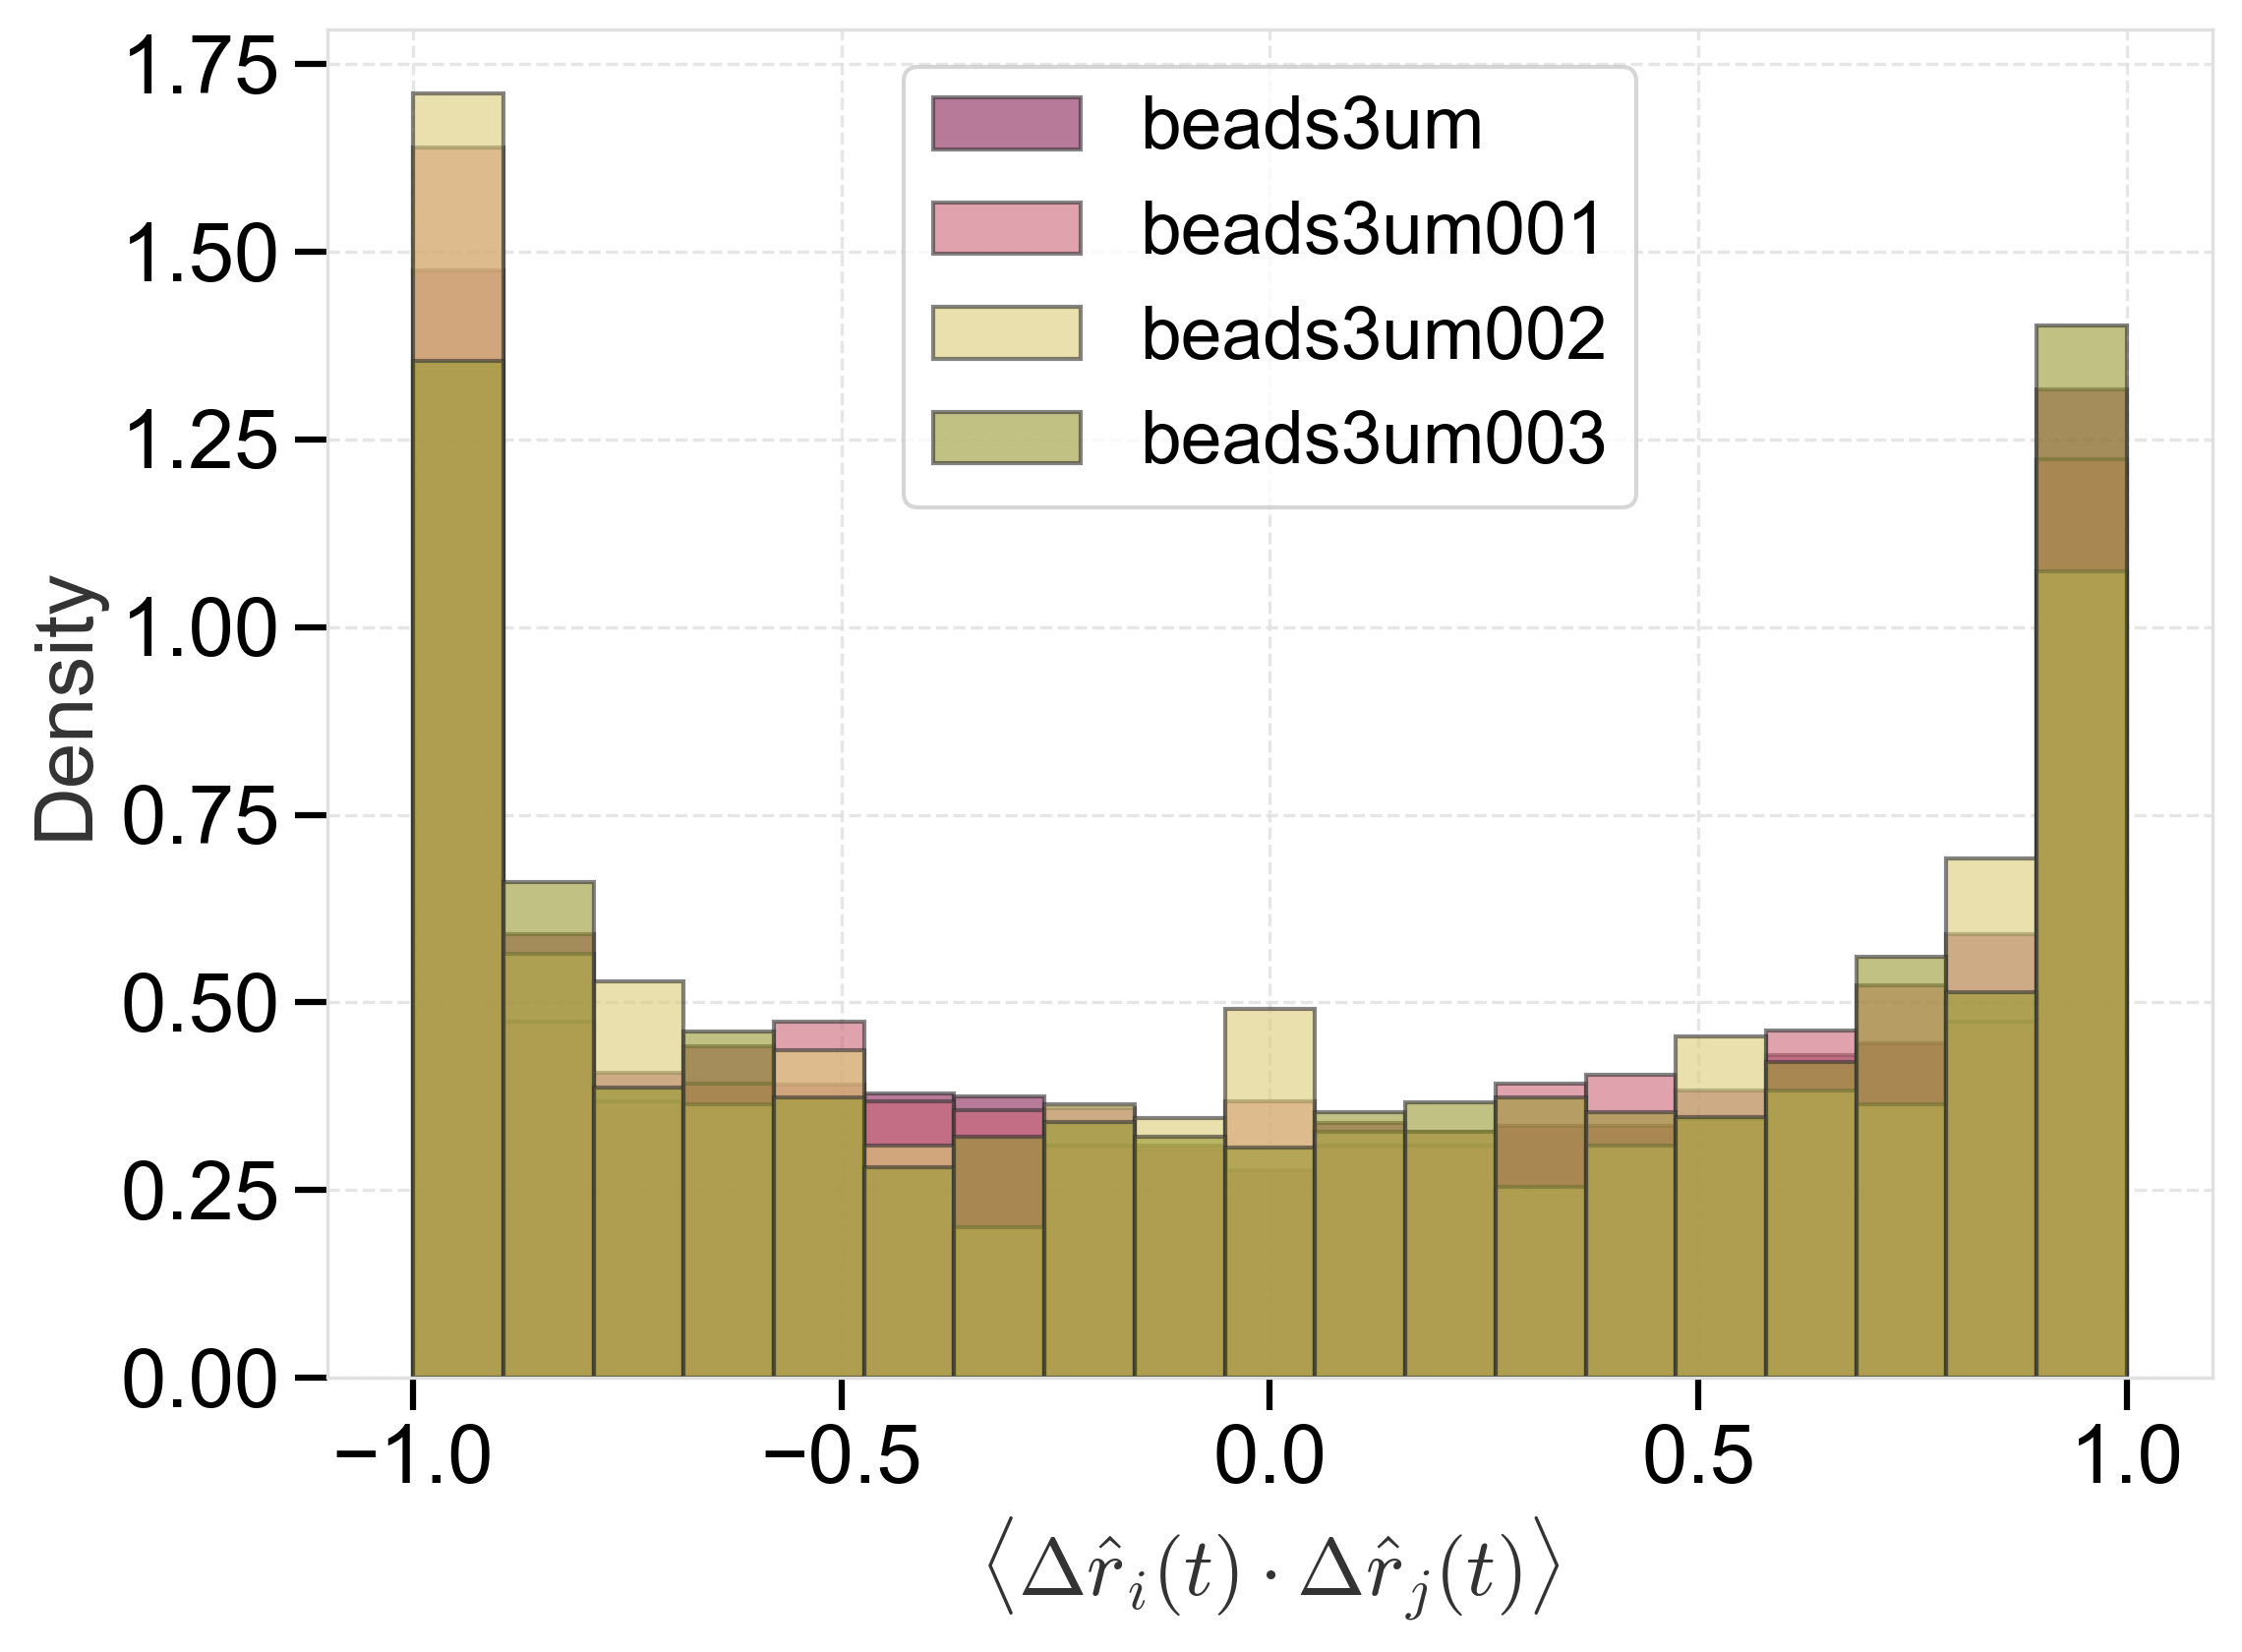

In [6]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr3.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads3um.pdf')

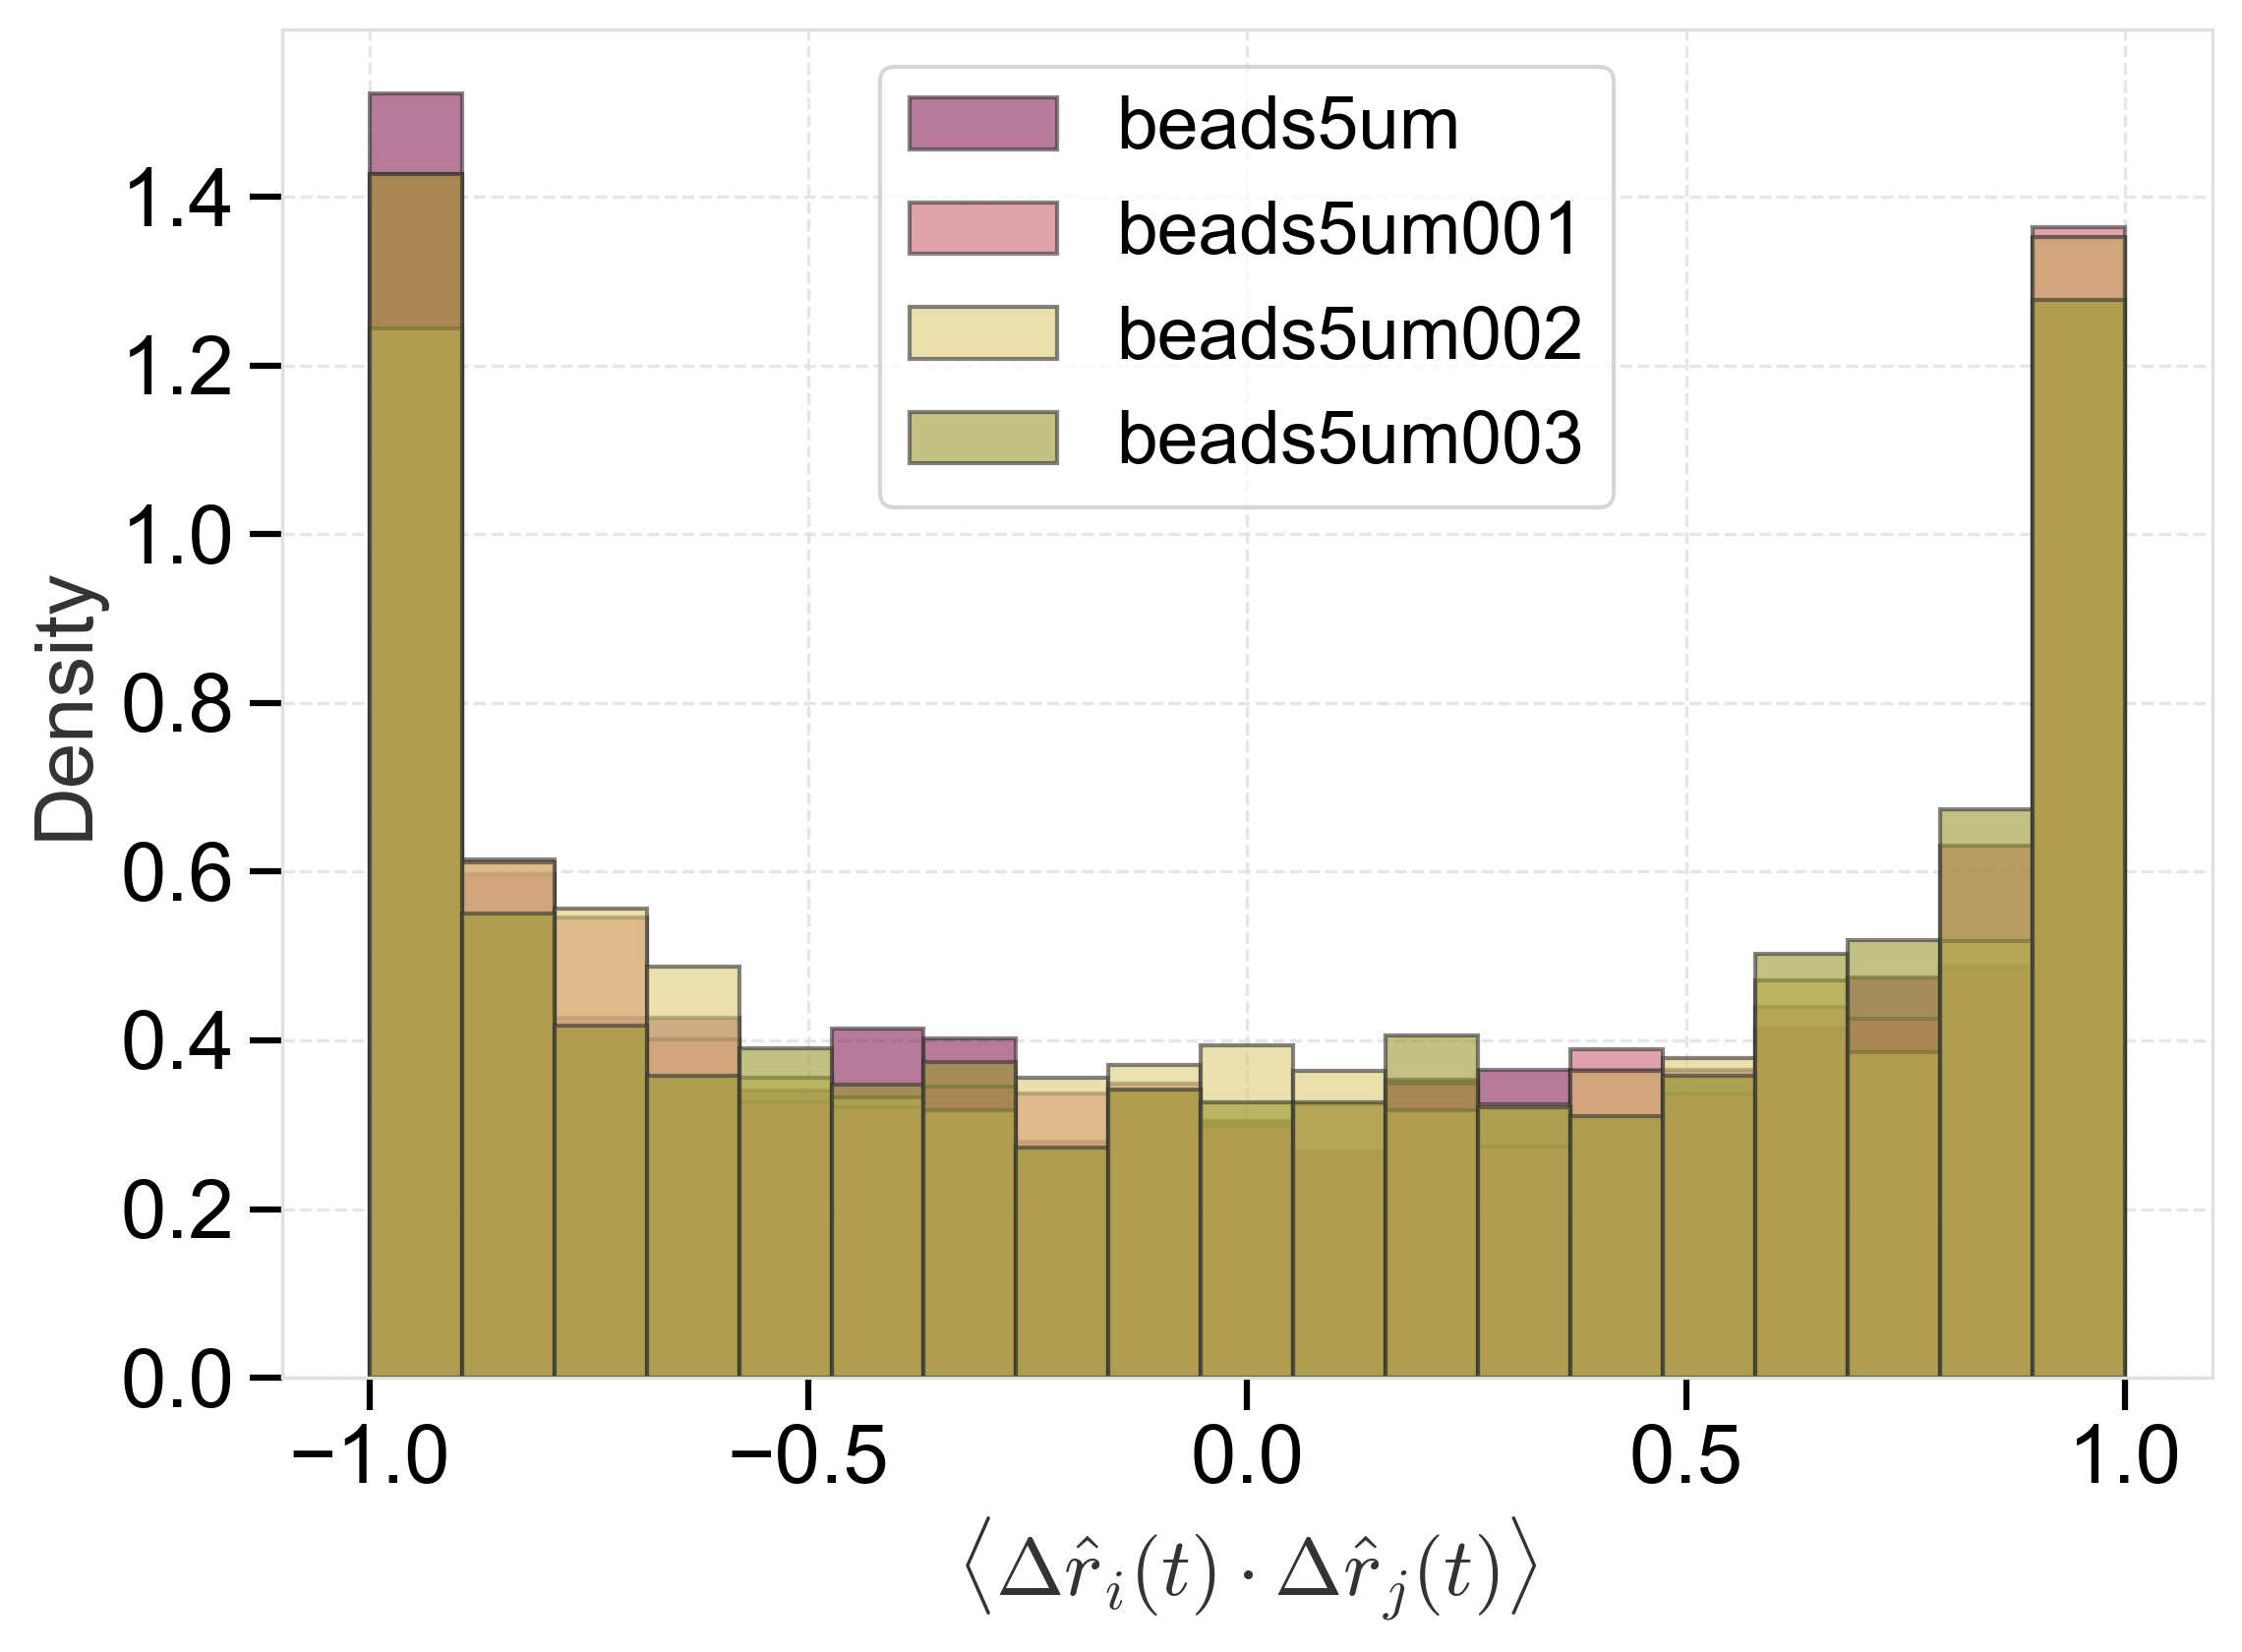

In [3]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr5.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads5um.pdf')

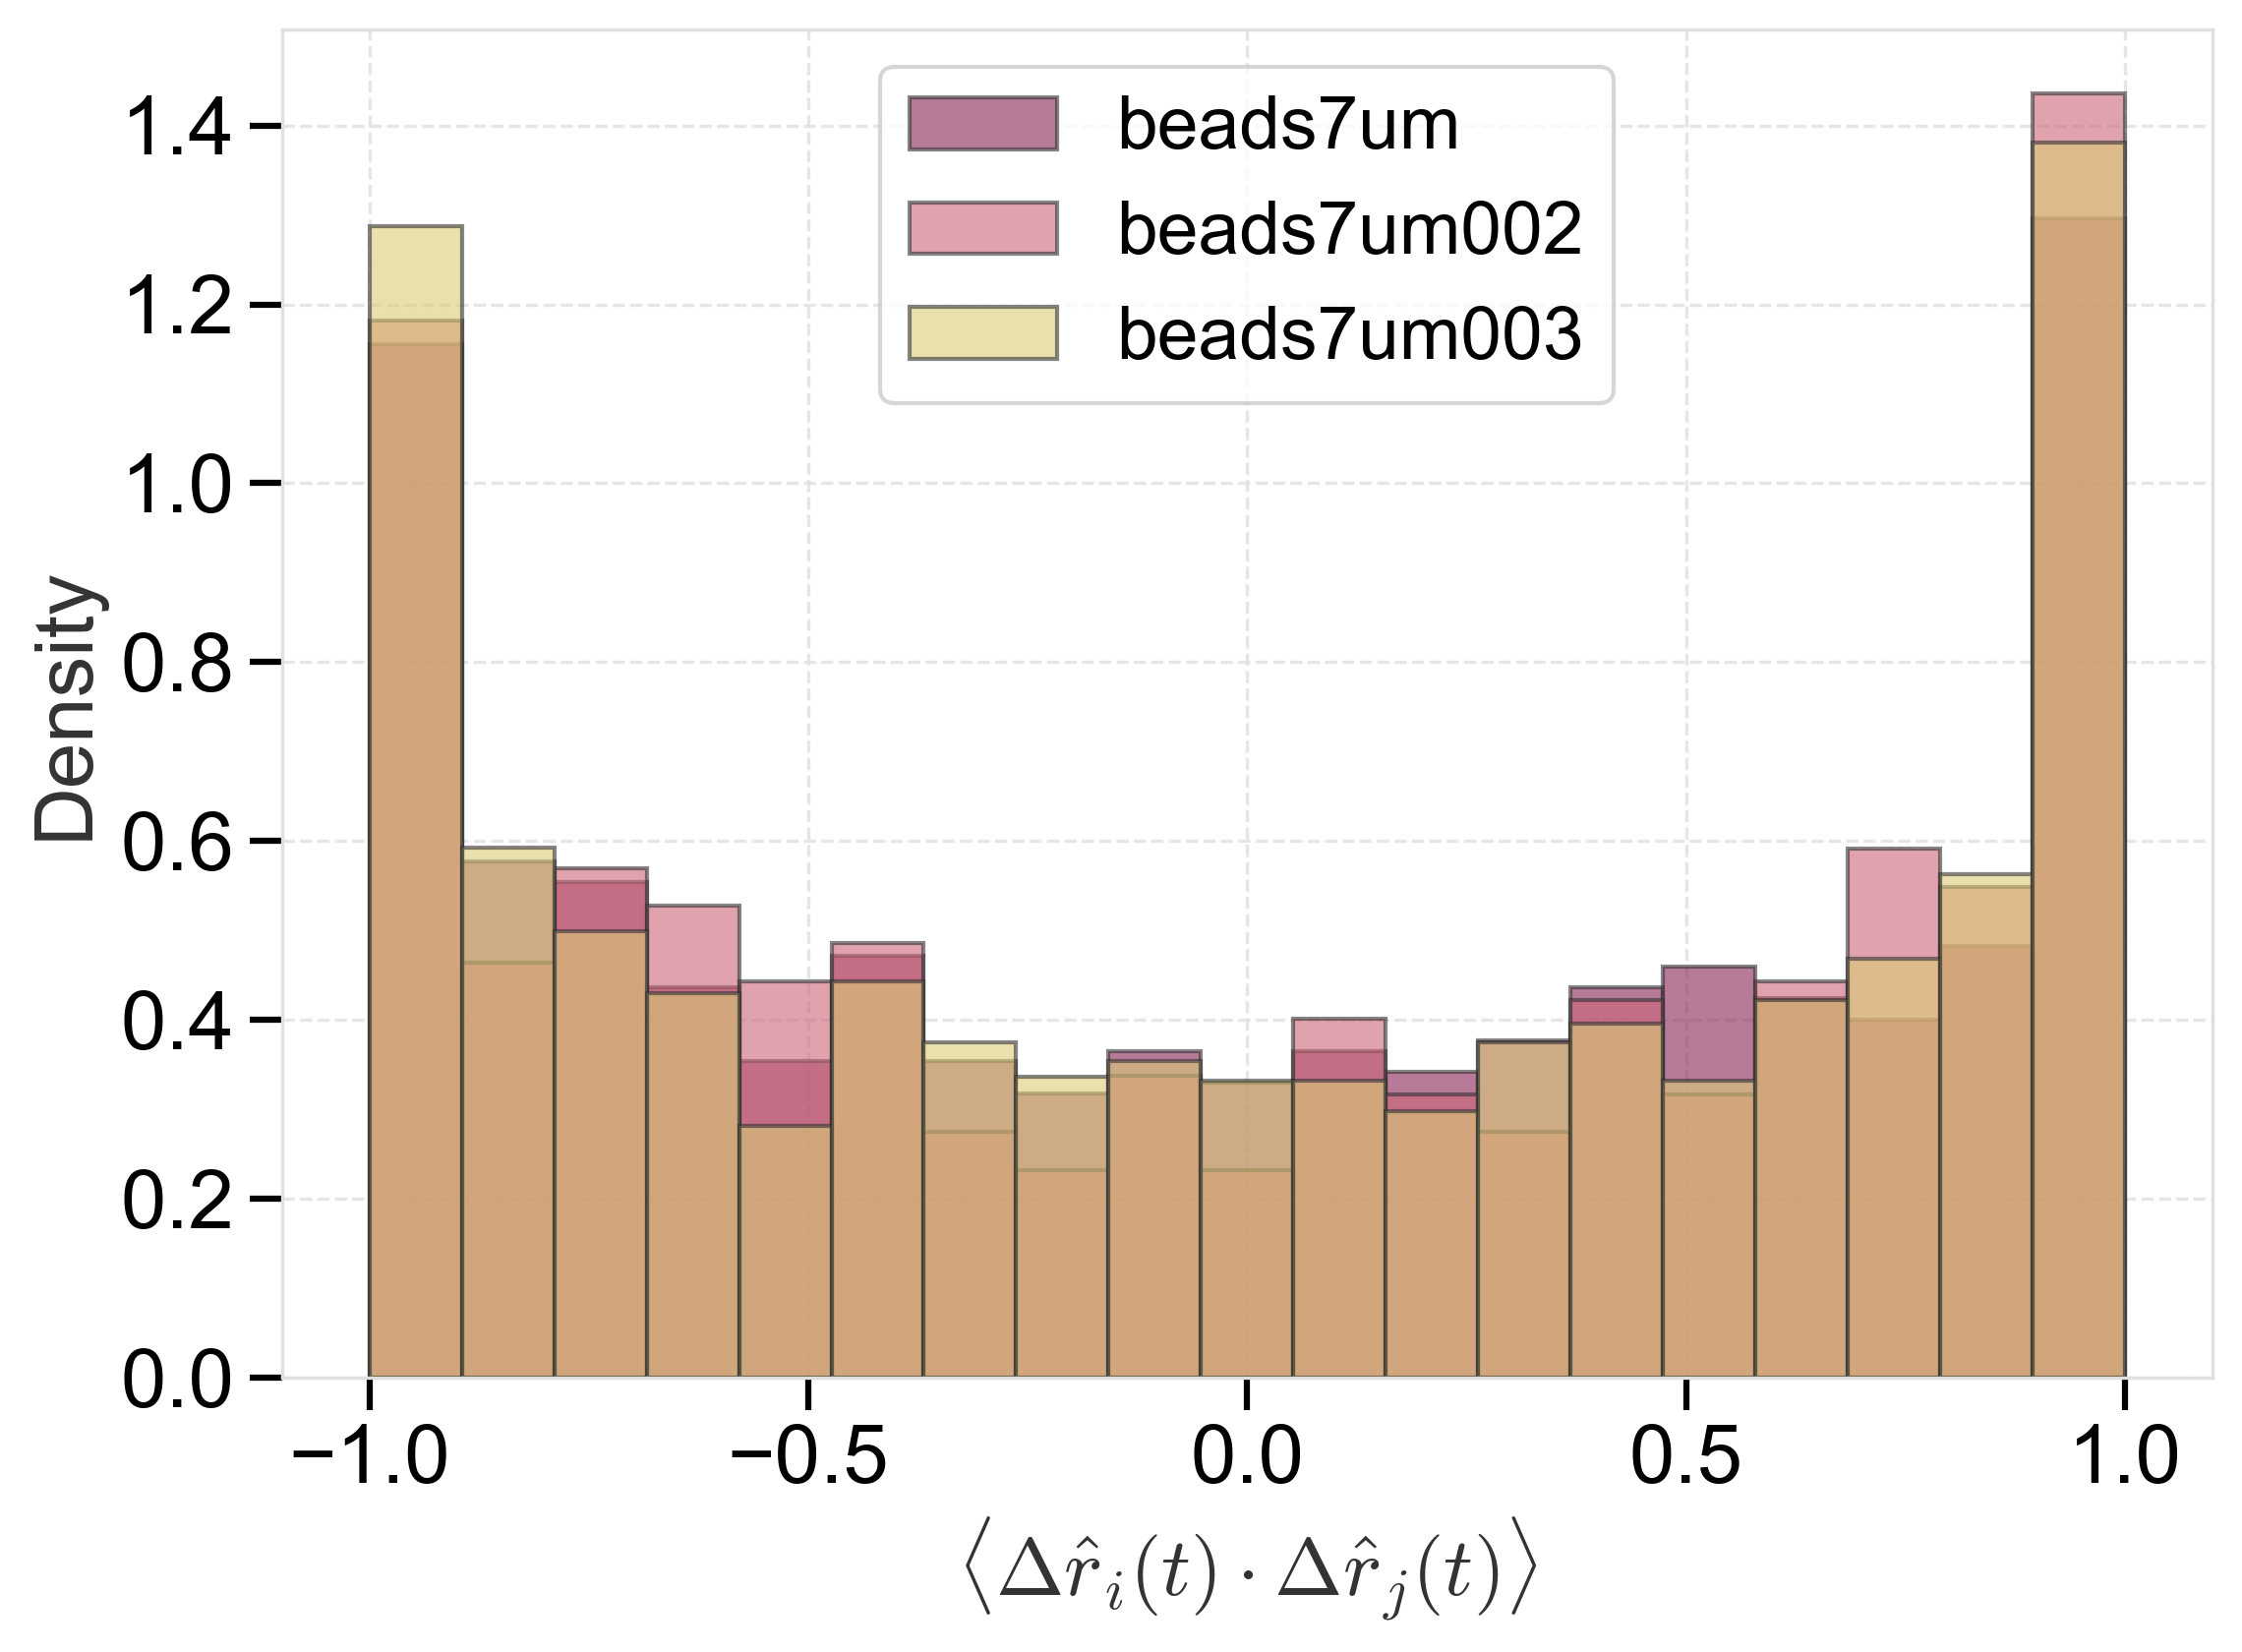

In [12]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr7.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads7um.pdf')